In [1]:
import os
import json
import time
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor
)

# Reproducibility
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Finally have GPU available on this computer
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [2]:
%load_ext tensorboard

In [3]:
%tensorboard --logdir runs_module_1_final_champ --port 6067

In [4]:
# ============================================================
# DATASET SIZE SELECTION
# ============================================================

DATA_FRACTION = 1

df_full = pd.read_parquet("CompoundData_WithEngineeredFeatures.parquet")

# Shuffle the ENTIRE dataset once in a reproducible order.
# Using the same RANDOM_STATE means smaller datasets are
# nested subsets of the larger datasets.
df_shuffled = df_full.sample(
    frac=1.0,
    random_state=RANDOM_STATE
).reset_index(drop=True)

# Select the requested fraction
n_samples = int(
    len(df_shuffled) * DATA_FRACTION
)

df = df_shuffled.iloc[
    :n_samples
].copy()

# Useful label for filenames / experiment tracking
DATA_LABEL = (
    f"{int(DATA_FRACTION * 100)}_percent_data"
)

print("Dataset:", DATA_LABEL)
print("Samples used:", len(df))
print("Total available:", len(df_full))


target_col = "BP"

selected_features = ['Vinylic', 'Arene', 'Alcohol',
                     'Ether', 'Amine', 'Ketone', 'Ester',
                     'CripA', 'CripB', 'PartialCharge',
                     'Radius of Gyration', 'Number of Rotatable Bonds',
                     'Morgan PC1', 'Morgan PC2']

model_df = df[selected_features + [target_col]].copy()

model_df = (
    model_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

X = model_df[selected_features].values.astype(np.float32)
y = model_df[target_col].values.astype(np.float32)

print("Features:", len(selected_features))
print("Total samples:", len(X))

Dataset: 100_percent_data
Samples used: 3312
Total available: 3312
Features: 14
Total samples: 3310


In [5]:
# ============================================================
# Neural-network definition
# ============================================================

class BPMLP(nn.Module):
    def __init__(self, input_size, hidden_layers, activation="relu"):
        super().__init__()

        activations = {
            "relu": nn.ReLU,
            "sigmoid": nn.Sigmoid
        }

        if activation.lower() not in activations:
            raise ValueError(f"Unknown activation: {activation}")

        activation_class = activations[activation.lower()]

        layers = []
        previous_size = input_size

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(previous_size, hidden_size))
            layers.append(activation_class())
            previous_size = hidden_size

        layers.append(nn.Linear(previous_size, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# ============================================================
# Helper function for run names
# ============================================================

def make_run_name(
    model_type,
    experiment_name=None
):

    if experiment_name is not None:
        return f"{experiment_name}__{model_type}"

    return model_type


# ============================================================
# Main training/evaluation function
# ============================================================

def train_model(
    X,
    y,

    model_type="mlp",
    model_params=None,

    learning_rate=1e-4,
    optimizer_name="adam",
    scheduler_name="cosine_warm_restarts",
    batch_size=0,

    max_epochs=10000,
    patience=300,
    min_delta=1e-5,

    experiment_name=None,
    verbose=True
):

    if model_params is None:
        model_params = {}

    model_type = model_type.lower()

    # ========================================================
    # 80/20 TRAINING / VALIDATION SPLIT
    # ========================================================

    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE
    )

    # ========================================================
    # SCALING
    # Fit scalers ONLY on training data
    # ========================================================

    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_val_scaled = scaler_X.transform(X_val)

    y_train_scaled = scaler_y.fit_transform(
        y_train.reshape(-1, 1)
    ).flatten()

    y_val_scaled = scaler_y.transform(
        y_val.reshape(-1, 1)
    ).flatten()

    # ========================================================
    # RUN NAME / TENSORBOARD
    # ========================================================

    run_name = make_run_name(
        model_type,
        experiment_name
    )

    writer = SummaryWriter(
        log_dir=f"runs_module_1_10_percent/{run_name}"
    )

    start_time = time.perf_counter()

    train_history = []
    val_history = []
    x_history = []

    best_val_loss = np.inf
    best_train_loss = np.inf
    best_step = None

    # This will eventually contain predictions from the
    # best version of whichever model is being used
    val_prediction_scaled = None

    # ========================================================
    # MLP
    # ========================================================

    if model_type == "mlp":

        hidden_layers = model_params.get(
            "hidden_layers",
            [64, 32]
        )

        activation = model_params.get(
            "activation",
            "relu"
        )

        model = BPMLP(
            input_size=X_train_scaled.shape[1],
            hidden_layers=hidden_layers,
            activation=activation
        ).to(device)

        # ----------------------------------------------------
        # Optimizer
        # ----------------------------------------------------

        optimizer_name = optimizer_name.lower()

        if optimizer_name == "adam":

            optimizer = torch.optim.Adam(
                model.parameters(),
                lr=learning_rate
            )

        elif optimizer_name == "sgd":

            optimizer = torch.optim.SGD(
                model.parameters(),
                lr=learning_rate,
                momentum=0.9
            )

        elif optimizer_name == "rmsprop":

            optimizer = torch.optim.RMSprop(
                model.parameters(),
                lr=learning_rate
            )

        else:

            raise ValueError(
                f"Unknown optimizer: {optimizer_name}"
            )

        # ----------------------------------------------------
        # Scheduler
        # ----------------------------------------------------

        scheduler_name = scheduler_name.lower()

        if scheduler_name == "none":

            scheduler = None

        elif scheduler_name == "step":

            scheduler = torch.optim.lr_scheduler.StepLR(
                optimizer,
                step_size=500,
                gamma=0.5
            )

        elif scheduler_name == "cosine":

            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer,
                T_max=max_epochs,
                eta_min=1e-6
            )

        elif scheduler_name == "cosine_warm_restarts":

            scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                optimizer,
                T_0=100,
                T_mult=2,
                eta_min=1e-5
            )

        elif scheduler_name == "plateau":

            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer,
                mode="min",
                factor=0.5,
                patience=50
            )

        else:

            raise ValueError(
                f"Unknown scheduler: {scheduler_name}"
            )

        criterion = nn.MSELoss()

        # ----------------------------------------------------
        # Tensors
        # ----------------------------------------------------

        X_train_tensor = torch.tensor(
            X_train_scaled,
            dtype=torch.float32
        )

        y_train_tensor = torch.tensor(
            y_train_scaled,
            dtype=torch.float32
        ).view(-1, 1)

        X_val_tensor = torch.tensor(
            X_val_scaled,
            dtype=torch.float32
        ).to(device)

        y_val_tensor = torch.tensor(
            y_val_scaled,
            dtype=torch.float32
        ).view(-1, 1).to(device)

        # ----------------------------------------------------
        # batch_size == 0 means full-batch training
        # ----------------------------------------------------

        if batch_size in [0, None]:

            effective_batch_size = len(
                X_train_tensor
            )

        else:

            effective_batch_size = batch_size

        train_dataset = TensorDataset(
            X_train_tensor,
            y_train_tensor
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=effective_batch_size,
            shuffle=True
        )

        best_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

        # ----------------------------------------------------
        # TRAINING LOOP
        # ----------------------------------------------------

        for epoch in range(max_epochs):

            model.train()

            for X_batch, y_batch in train_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                optimizer.zero_grad()

                predictions = model(X_batch)

                loss = criterion(
                    predictions,
                    y_batch
                )

                loss.backward()

                optimizer.step()

            # ------------------------------------------------
            # Evaluate complete training/validation sets
            # ------------------------------------------------

            model.eval()

            with torch.no_grad():

                X_train_eval = torch.tensor(
                    X_train_scaled,
                    dtype=torch.float32
                ).to(device)

                y_train_eval = torch.tensor(
                    y_train_scaled,
                    dtype=torch.float32
                ).view(-1, 1).to(device)

                train_pred = model(
                    X_train_eval
                )

                val_pred = model(
                    X_val_tensor
                )

                train_loss = criterion(
                    train_pred,
                    y_train_eval
                ).item() * 1000

                val_loss = criterion(
                    val_pred,
                    y_val_tensor
                ).item() * 1000

            train_history.append(
                train_loss
            )

            val_history.append(
                val_loss
            )

            x_history.append(
                epoch + 1
            )

            current_lr = (
                optimizer
                .param_groups[0]["lr"]
            )

            writer.add_scalar(
                "Loss/train",
                train_loss,
                epoch
            )

            writer.add_scalar(
                "Loss/validation",
                val_loss,
                epoch
            )

            writer.add_scalar(
                "Learning Rate",
                current_lr,
                epoch
            )

            # ------------------------------------------------
            # Scheduler
            # ------------------------------------------------

            if scheduler is not None:

                if scheduler_name == "plateau":

                    scheduler.step(
                        val_loss
                    )

                else:

                    scheduler.step()

            # ------------------------------------------------
            # Early stopping
            # ------------------------------------------------

            if val_loss < best_val_loss - min_delta:

                best_val_loss = val_loss
                best_train_loss = train_loss
                best_step = epoch + 1

                best_state = copy.deepcopy(
                    model.state_dict()
                )

                epochs_without_improvement = 0

            else:

                epochs_without_improvement += 1

            if verbose and (epoch + 1) % 100 == 0:

                print(
                    f"{run_name} | "
                    f"Epoch {epoch + 1} | "
                    f"Train = {train_loss:.3f} | "
                    f"Val = {val_loss:.3f}"
                )

            if epochs_without_improvement >= patience:

                if verbose:

                    print(
                        f"Early stopping at "
                        f"epoch {epoch + 1}"
                    )

                break

        # ----------------------------------------------------
        # Restore model from minimum validation loss
        # ----------------------------------------------------

        model.load_state_dict(
            best_state
        )

        model.eval()

        with torch.no_grad():

            val_prediction_scaled = (
                model(X_val_tensor)
                .cpu()
                .numpy()
                .flatten()
            )

    # ========================================================
    # RANDOM FOREST
    # ========================================================

    elif model_type == "random_forest":

        n_estimators = model_params.get(
            "n_estimators",
            300
        )

        max_depth = model_params.get(
            "max_depth",
            None
        )

        min_samples_leaf = model_params.get(
            "min_samples_leaf",
            1
        )

        max_features = model_params.get(
            "max_features",
            1.0
        )

        # Add trees incrementally so validation loss can be
        # plotted as a function of number of trees
        step_size = max(
            10,
            min(25, n_estimators)
        )

        model = RandomForestRegressor(
            n_estimators=step_size,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            warm_start=True
        )

        best_n_estimators = step_size

        for n_trees in range(
            step_size,
            n_estimators + 1,
            step_size
        ):

            model.set_params(
                n_estimators=n_trees
            )

            model.fit(
                X_train_scaled,
                y_train_scaled
            )

            train_pred = model.predict(
                X_train_scaled
            )

            val_pred = model.predict(
                X_val_scaled
            )

            train_loss = mean_squared_error(
                y_train_scaled,
                train_pred
            ) * 1000

            val_loss = mean_squared_error(
                y_val_scaled,
                val_pred
            ) * 1000

            train_history.append(
                train_loss
            )

            val_history.append(
                val_loss
            )

            x_history.append(
                n_trees
            )

            writer.add_scalar(
                "Loss/train",
                train_loss,
                n_trees
            )

            writer.add_scalar(
                "Loss/validation",
                val_loss,
                n_trees
            )

            if val_loss < best_val_loss:

                best_val_loss = val_loss
                best_train_loss = train_loss
                best_step = n_trees
                best_n_estimators = n_trees

        # Refit using the number of trees that gave
        # minimum validation loss
        model = RandomForestRegressor(
            n_estimators=best_n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

        model.fit(
            X_train_scaled,
            y_train_scaled
        )

        val_prediction_scaled = model.predict(
            X_val_scaled
        )

    # ========================================================
    # EXTRA TREES
    # ========================================================

    elif model_type == "extra_trees":

        n_estimators = model_params.get(
            "n_estimators",
            300
        )

        max_depth = model_params.get(
            "max_depth",
            None
        )

        min_samples_leaf = model_params.get(
            "min_samples_leaf",
            1
        )

        model = ExtraTreesRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

        model.fit(
            X_train_scaled,
            y_train_scaled
        )

        train_pred = model.predict(
            X_train_scaled
        )

        val_prediction_scaled = model.predict(
            X_val_scaled
        )

        best_train_loss = mean_squared_error(
            y_train_scaled,
            train_pred
        ) * 1000

        best_val_loss = mean_squared_error(
            y_val_scaled,
            val_prediction_scaled
        ) * 1000

        best_step = n_estimators

        train_history = [
            best_train_loss
        ]

        val_history = [
            best_val_loss
        ]

        x_history = [
            n_estimators
        ]

        writer.add_scalar(
            "Loss/train",
            best_train_loss,
            n_estimators
        )

        writer.add_scalar(
            "Loss/validation",
            best_val_loss,
            n_estimators
        )

    # ========================================================
    # FINAL VALIDATION RESULTS
    # ========================================================

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    # Same standardized MSE * 1000 convention
    # as the class baseline
    final_val_loss = mean_squared_error(
        y_val_scaled,
        val_prediction_scaled
    ) * 1000

    # Convert validation predictions back into
    # original BP units
    val_prediction = scaler_y.inverse_transform(
        np.asarray(
            val_prediction_scaled
        ).reshape(-1, 1)
    ).flatten()

    val_mse = mean_squared_error(
        y_val,
        val_prediction
    )

    val_mae = mean_absolute_error(
        y_val,
        val_prediction
    )

    val_r2 = r2_score(
        y_val,
        val_prediction
    )

    # ========================================================
    # TENSORBOARD METADATA
    # ========================================================

    writer.add_text(
        "Parameters",
        json.dumps(
            {
                "model_type": model_type,
                "learning_rate": learning_rate,
                "optimizer": optimizer_name,
                "scheduler": scheduler_name,
                "batch_size": batch_size,
                "model_params": model_params
            },
            indent=2
        )
    )

    writer.add_scalar(
        "Final/validation_loss_scaled_x1000",
        final_val_loss,
        0
    )

    writer.add_scalar(
        "Final/validation_MSE_BP_units",
        val_mse,
        0
    )

    writer.add_scalar(
        "Final/validation_MAE",
        val_mae,
        0
    )

    writer.add_scalar(
        "Final/validation_R2",
        val_r2,
        0
    )

    writer.close()

    # ========================================================
    # RESULTS ROW
    # ========================================================

    result_row = {

        "run_name":
            run_name,

        "experiment":
            experiment_name,

        "model_type":
            model_type,

        "learning_rate":
            learning_rate
            if model_type == "mlp"
            else np.nan,

        "optimizer":
            optimizer_name
            if model_type == "mlp"
            else "N/A",

        "scheduler":
            scheduler_name
            if model_type == "mlp"
            else "N/A",

        "batch_size":
            batch_size
            if model_type == "mlp"
            else np.nan,

        "model_params":
            json.dumps(
                model_params,
                sort_keys=True
            ),

        "best_step":
            best_step,

        "best_train_loss":
            best_train_loss,

        "best_val_loss":
            best_val_loss,

        "final_val_loss":
            final_val_loss,

        "val_mse":
            val_mse,

        "val_mae":
            val_mae,

        "val_r2":
            val_r2,

        "execution_time_sec":
            elapsed_time,

        "n_train":
            len(X_train),

        "n_validation":
            len(X_val)
    }

    # ========================================================
    # LOSS HISTORY
    # ========================================================

    history = {

        "run_name":
            run_name,

        "model_type":
            model_type,

        "x":
            x_history,

        "train_loss":
            train_history,

        "val_loss":
            val_history
    }

    return result_row, history

In [55]:
# ============================================================
# CONTROL CELL
# ============================================================

results = []
histories = {}

# ============================================================
# BASELINE SETTINGS
# ============================================================

baseline_nn_params = {
    "hidden_layers": [64, 32],
    "activation": "relu"
}

baseline_learning_rate = 1e-4
baseline_optimizer = "adam"
baseline_scheduler = "cosine_warm_restarts"
baseline_batch_size = 0


# ============================================================
# 1. BASELINE MODEL
# ============================================================

row, history = train_model(
    X,
    y,

    model_type="mlp",
    model_params=baseline_nn_params,

    learning_rate=baseline_learning_rate,
    optimizer_name=baseline_optimizer,
    scheduler_name=baseline_scheduler,
    batch_size=baseline_batch_size,

    max_epochs=10000,
    patience=300,

    experiment_name="baseline"
)

row["factor"] = "baseline"
row["setting"] = "baseline"

results.append(row)
histories[row["run_name"]] = history


# ============================================================
# 2. LEARNING RATE
# ============================================================

learning_rates = [
    1e-5,
    5e-5,
    3e-4,
    1e-3,
    5e-3
]

for lr in learning_rates:

    row, history = train_model(
        X,
        y,

        model_type="mlp",
        model_params=baseline_nn_params,

        learning_rate=lr,
        optimizer_name=baseline_optimizer,
        scheduler_name=baseline_scheduler,
        batch_size=baseline_batch_size,

        max_epochs=10000,
        patience=300,

        experiment_name=f"learning_rate_{lr}"
    )

    row["factor"] = "learning_rate"
    row["setting"] = lr

    results.append(row)
    histories[row["run_name"]] = history


# ============================================================
# 3. OPTIMIZER
# ============================================================

optimizers = [
    "sgd",
    "rmsprop",
    "adam"
]

for optimizer in optimizers:

    row, history = train_model(
        X,
        y,

        model_type="mlp",
        model_params=baseline_nn_params,

        learning_rate=baseline_learning_rate,
        optimizer_name=optimizer,
        scheduler_name=baseline_scheduler,
        batch_size=baseline_batch_size,

        max_epochs=10000,
        patience=300,

        experiment_name=f"optimizer_{optimizer}"
    )

    row["factor"] = "optimizer"
    row["setting"] = optimizer

    results.append(row)
    histories[row["run_name"]] = history


# ============================================================
# 4. SCHEDULER
# ============================================================

schedulers = [
    "none",
    "step",
    "cosine",
    "cosine_warm_restarts",
    "plateau"
]

for scheduler in schedulers:

    row, history = train_model(
        X,
        y,

        model_type="mlp",
        model_params=baseline_nn_params,

        learning_rate=baseline_learning_rate,
        optimizer_name=baseline_optimizer,
        scheduler_name=scheduler,
        batch_size=baseline_batch_size,

        max_epochs=10000,
        patience=300,

        experiment_name=f"scheduler_{scheduler}"
    )

    row["factor"] = "scheduler"
    row["setting"] = scheduler

    results.append(row)
    histories[row["run_name"]] = history


# ============================================================
# 5. BATCH SIZE
#
# batch_size = 0 means full-batch training
# ============================================================

batch_sizes = [
    16,
    32,
    128,
    512,
    0
]

for batch_size in batch_sizes:

    row, history = train_model(
        X,
        y,

        model_type="mlp",
        model_params=baseline_nn_params,

        learning_rate=baseline_learning_rate,
        optimizer_name=baseline_optimizer,
        scheduler_name=baseline_scheduler,
        batch_size=batch_size,

        max_epochs=10000,
        patience=300,

        experiment_name=f"batch_size_{batch_size}"
    )

    row["factor"] = "batch_size"
    row["setting"] = batch_size

    results.append(row)
    histories[row["run_name"]] = history


# ============================================================
# 6. NEURAL NETWORK ARCHITECTURE / ACTIVATION
# ============================================================

nn_architectures = [
    [16],
    [64, 32],
    [128, 64, 32]
]

activations = [
    "relu",
    "sigmoid"
]

for architecture in nn_architectures:

    for activation in activations:

        params = {
            "hidden_layers": architecture,
            "activation": activation
        }

        setting_name = (
            f"{'-'.join(map(str, architecture))}_"
            f"{activation}"
        )

        row, history = train_model(
            X,
            y,

            model_type="mlp",
            model_params=params,

            learning_rate=baseline_learning_rate,
            optimizer_name=baseline_optimizer,
            scheduler_name=baseline_scheduler,
            batch_size=baseline_batch_size,

            max_epochs=10000,
            patience=300,

            experiment_name=f"NN_{setting_name}"
        )

        row["factor"] = "nn_architecture"
        row["setting"] = setting_name

        results.append(row)
        histories[row["run_name"]] = history


# ============================================================
# 7. RANDOM FOREST CONFIGURATIONS
# ============================================================

rf_configs = [

    {
        "n_estimators": 50,
        "max_depth": 3,
        "min_samples_leaf": 10
    },

    {
        "n_estimators": 100,
        "max_depth": 5,
        "min_samples_leaf": 5
    },

    {
        "n_estimators": 200,
        "max_depth": 10,
        "min_samples_leaf": 2
    },

    {
        "n_estimators": 300,
        "max_depth": 20,
        "min_samples_leaf": 1
    },

    {
        "n_estimators": 500,
        "max_depth": None,
        "min_samples_leaf": 2
    },

    {
        "n_estimators": 750,
        "max_depth": None,
        "min_samples_leaf": 1
    }
]


for i, params in enumerate(rf_configs):

    row, history = train_model(
        X,
        y,

        model_type="random_forest",
        model_params=params,

        experiment_name=f"RF_{i + 1}"
    )

    row["factor"] = "random_forest_configuration"
    row["setting"] = f"RF_{i + 1}"

    results.append(row)
    histories[row["run_name"]] = history


# ============================================================
# 8. EXTRA TREES CONFIGURATIONS
# ============================================================

extra_tree_configs = [

    {
        "n_estimators": 50,
        "max_depth": 3,
        "min_samples_leaf": 10
    },

    {
        "n_estimators": 100,
        "max_depth": 5,
        "min_samples_leaf": 5
    },

    {
        "n_estimators": 200,
        "max_depth": 10,
        "min_samples_leaf": 2
    },

    {
        "n_estimators": 300,
        "max_depth": 20,
        "min_samples_leaf": 1
    },

    {
        "n_estimators": 500,
        "max_depth": None,
        "min_samples_leaf": 2
    },

    {
        "n_estimators": 750,
        "max_depth": None,
        "min_samples_leaf": 1
    }
]


for i, params in enumerate(extra_tree_configs):

    row, history = train_model(
        X,
        y,

        model_type="extra_trees",
        model_params=params,

        experiment_name=f"ExtraTrees_{i + 1}"
    )

    row["factor"] = "extra_trees_configuration"
    row["setting"] = f"ExtraTrees_{i + 1}"

    results.append(row)
    histories[row["run_name"]] = history


# ============================================================
# CREATE RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "best_val_loss"
).reset_index(drop=True)

display(results_df)


# ============================================================
# SAVE RESULTS
# ============================================================

results_df.to_csv(
    "model_experiment_results_50_percent.csv",
    index=False
)

print(
    "\nBest model so far:"
)

display(
    results_df[
        [
            "run_name",
            "model_type",
            "best_train_loss",
            "best_val_loss",
            "val_mse",
            "val_mae",
            "val_r2",
            "best_step",
            "execution_time_sec"
        ]
    ].head(10)
)

baseline__mlp | Epoch 100 | Train = 810.081 | Val = 645.930
baseline__mlp | Epoch 200 | Train = 560.872 | Val = 424.612
baseline__mlp | Epoch 300 | Train = 493.366 | Val = 366.264
baseline__mlp | Epoch 400 | Train = 351.775 | Val = 251.925
baseline__mlp | Epoch 500 | Train = 310.324 | Val = 222.887
baseline__mlp | Epoch 600 | Train = 295.429 | Val = 212.897
baseline__mlp | Epoch 700 | Train = 290.474 | Val = 209.505
baseline__mlp | Epoch 800 | Train = 261.332 | Val = 194.535
baseline__mlp | Epoch 900 | Train = 239.011 | Val = 190.536
baseline__mlp | Epoch 1000 | Train = 220.638 | Val = 190.953
baseline__mlp | Epoch 1100 | Train = 206.743 | Val = 194.599
baseline__mlp | Epoch 1200 | Train = 197.844 | Val = 197.784
Early stopping at epoch 1246
learning_rate_1e-05__mlp | Epoch 100 | Train = 1011.938 | Val = 771.512
learning_rate_1e-05__mlp | Epoch 200 | Train = 990.641 | Val = 753.370
learning_rate_1e-05__mlp | Epoch 300 | Train = 969.223 | Val = 735.665
learning_rate_1e-05__mlp | Epoch 4

,run_name,experiment,model_type,learning_rate,optimizer,scheduler,batch_size,model_params,best_step,best_train_loss,best_val_loss,final_val_loss,val_mse,val_mae,val_r2,execution_time_sec,n_train,n_validation,factor,setting
0,learning_rate_0.005__mlp,learning_rate_0.005,mlp,0.00500,adam,cosine_warm_restarts,0.0,"{""activation"": ""relu"", ""hidden_layers"": [64, 32]}",331,18.257914,159.751490,159.751490,858.893188,19.431465,0.791472,4.417167,264,67,learning_rate,0.005
1,NN_128-64-32_relu__mlp,NN_128-64-32_relu,mlp,0.00010,adam,cosine_warm_restarts,0.0,"{""activation"": ""relu"", ""hidden_layers"": [128, ...",1663,45.981415,167.343810,167.343825,899.712708,19.029440,0.781562,16.819593,264,67,nn_architecture,128-64-32_relu
2,learning_rate_0.001__mlp,learning_rate_0.001,mlp,0.00100,adam,cosine_warm_restarts,0.0,"{""activation"": ""relu"", ""hidden_layers"": [64, 32]}",496,41.927997,177.319139,177.319139,953.344360,19.709002,0.768541,6.766022,264,67,learning_rate,0.001
3,batch_size_16__mlp,batch_size_16,mlp,0.00010,adam,cosine_warm_restarts,16.0,"{""activation"": ""relu"", ""hidden_layers"": [64, 32]}",154,198.983938,180.125684,180.125698,968.433777,20.856785,0.764877,15.478152,264,67,batch_size,16
4,scheduler_cosine__mlp,scheduler_cosine,mlp,0.00010,adam,cosine,0.0,"{""activation"": ""relu"", ""hidden_layers"": [64, 32]}",977,141.634494,183.649257,183.649272,987.378174,21.339222,0.760278,10.541458,264,67,scheduler,cosine
5,batch_size_128__mlp,batch_size_128,mlp,0.00010,adam,cosine_warm_restarts,128.0,"{""activation"": ""relu"", ""hidden_layers"": [64, 32]}",806,210.259050,187.433511,187.433511,1007.723877,21.115013,0.755338,12.142100,264,67,batch_size,128
6,learning_rate_0.0003__mlp,learning_rate_0.0003,mlp,0.00030,adam,cosine_warm_restarts,0.0,"{""activation"": ""relu"", ""hidden_layers"": [64, 32]}",413,182.343408,190.376922,190.376922,1023.548767,21.284592,0.751496,5.369144,264,67,learning_rate,0.0003
7,baseline__mlp,baseline,mlp,0.00010,adam,cosine_warm_restarts,0.0,"{""activation"": ""relu"", ""hidden_layers"": [64, 32]}",946,230.120644,190.459102,190.459117,1023.990784,21.905542,0.751388,12.944912,264,67,baseline,baseline
8,scheduler_none__mlp,scheduler_none,mlp,0.00010,adam,none,0.0,"{""activation"": ""relu"", ""hidden_layers"": [64, 32]}",888,179.526255,196.466088,196.466103,1056.286865,21.314823,0.743547,8.442298,264,67,scheduler,none
9,NN_64-32_relu__mlp,NN_64-32_relu,mlp,0.00010,adam,cosine_warm_restarts,0.0,"{""activation"": ""relu"", ""hidden_layers"": [64, 32]}",1248,182.374448,197.468027,197.468042,1061.673950,21.529800,0.742239,11.914852,264,67,nn_architecture,64-32_relu



Best model so far:


,run_name,model_type,best_train_loss,best_val_loss,val_mse,val_mae,val_r2,best_step,execution_time_sec
0,learning_rate_0.005__mlp,mlp,18.257914,159.751490,858.893188,19.431465,0.791472,331,4.417167
1,NN_128-64-32_relu__mlp,mlp,45.981415,167.343810,899.712708,19.029440,0.781562,1663,16.819593
2,learning_rate_0.001__mlp,mlp,41.927997,177.319139,953.344360,19.709002,0.768541,496,6.766022
3,batch_size_16__mlp,mlp,198.983938,180.125684,968.433777,20.856785,0.764877,154,15.478152
4,scheduler_cosine__mlp,mlp,141.634494,183.649257,987.378174,21.339222,0.760278,977,10.541458
5,batch_size_128__mlp,mlp,210.259050,187.433511,1007.723877,21.115013,0.755338,806,12.142100
6,learning_rate_0.0003__mlp,mlp,182.343408,190.376922,1023.548767,21.284592,0.751496,413,5.369144
7,baseline__mlp,mlp,230.120644,190.459102,1023.990784,21.905542,0.751388,946,12.944912
8,scheduler_none__mlp,mlp,179.526255,196.466088,1056.286865,21.314823,0.743547,888,8.442298
9,NN_64-32_relu__mlp,mlp,182.374448,197.468027,1061.673950,21.529800,0.742239,1248,11.914852


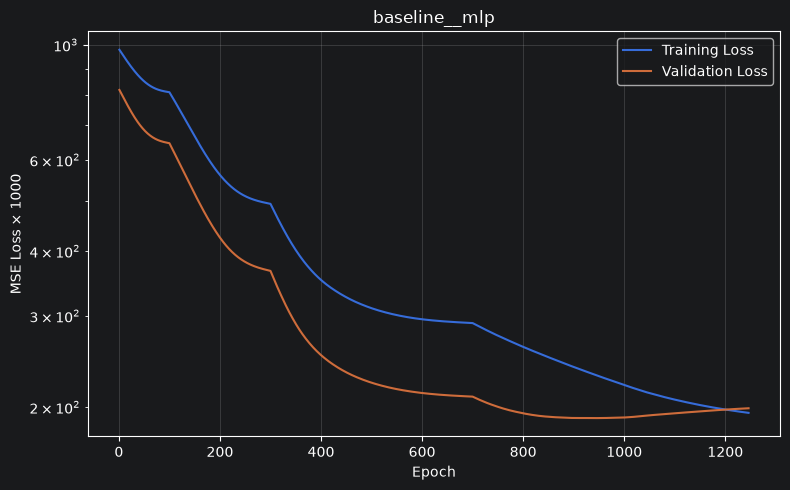

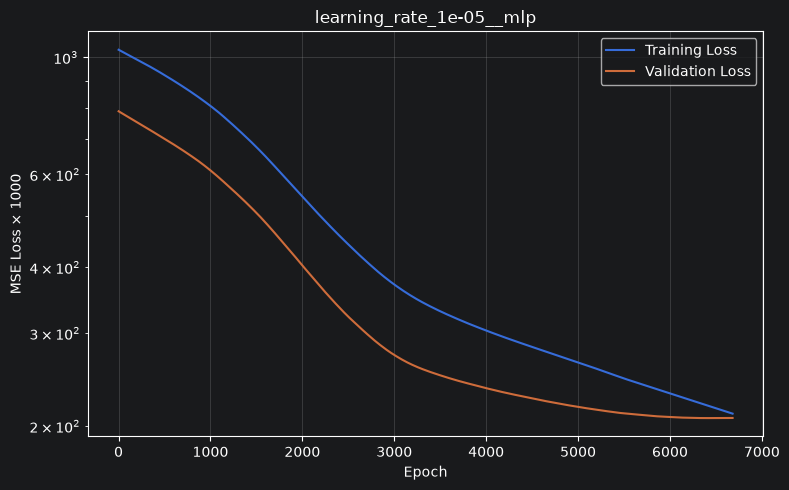

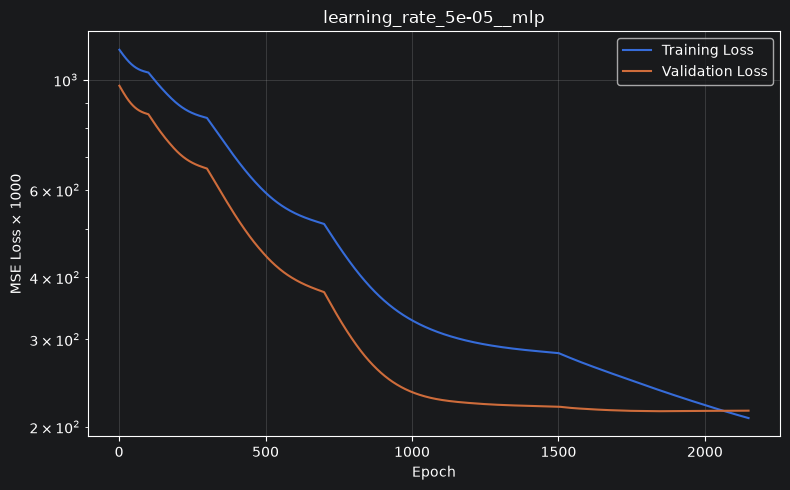

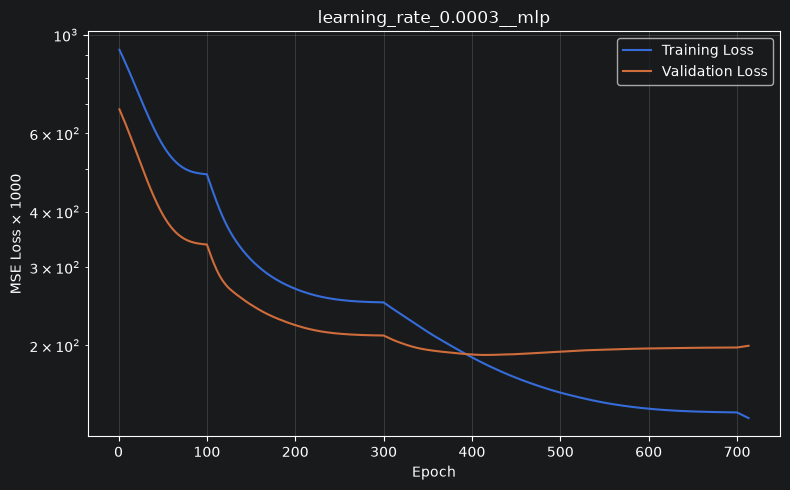

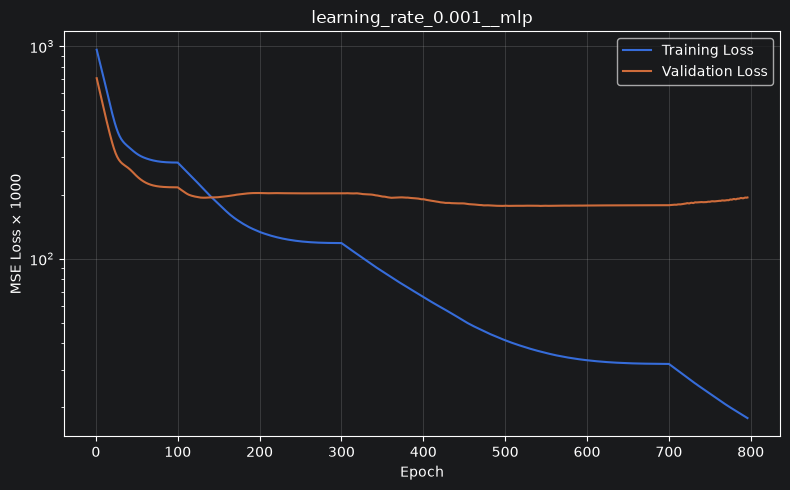

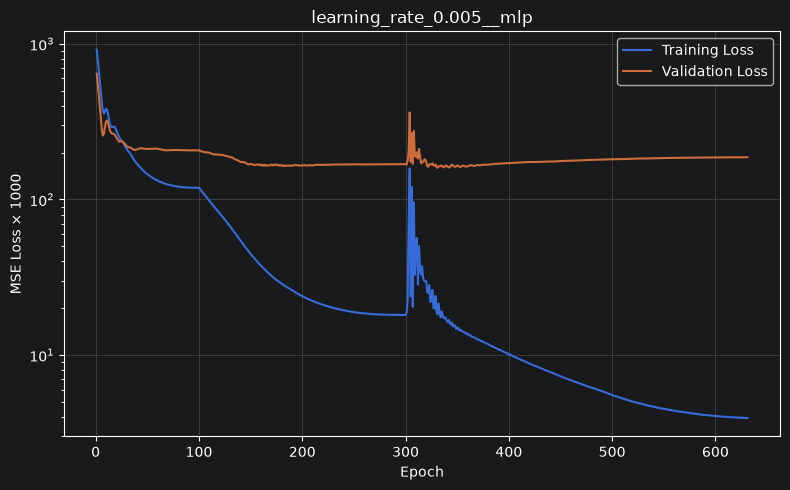

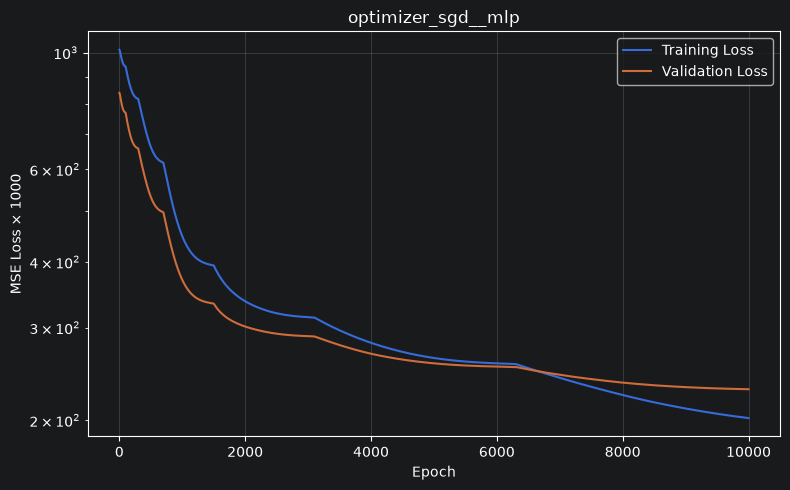

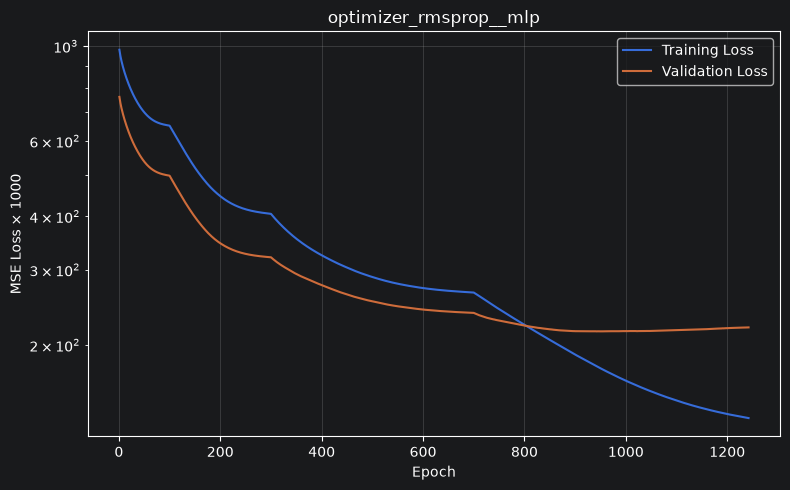

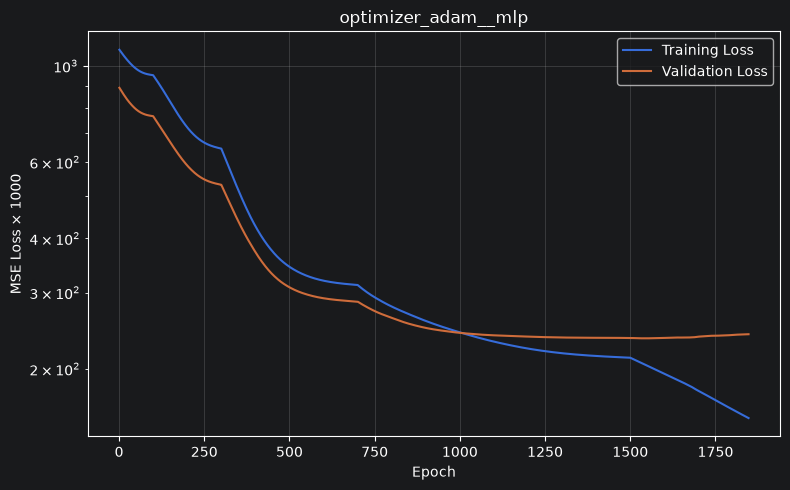

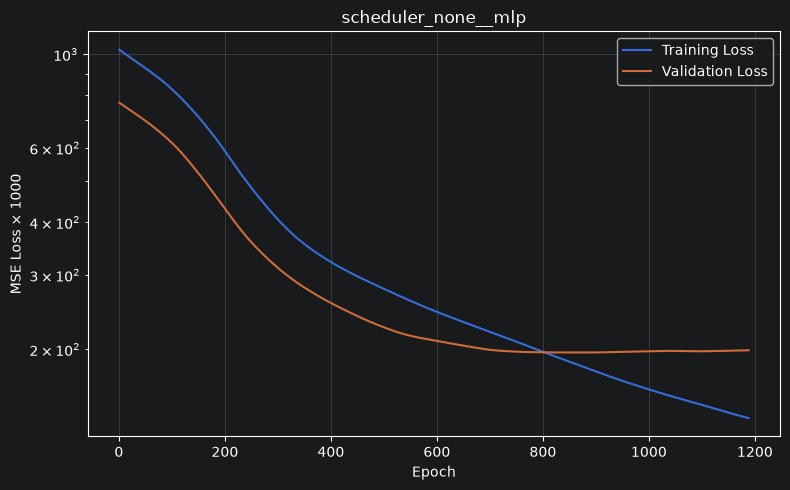

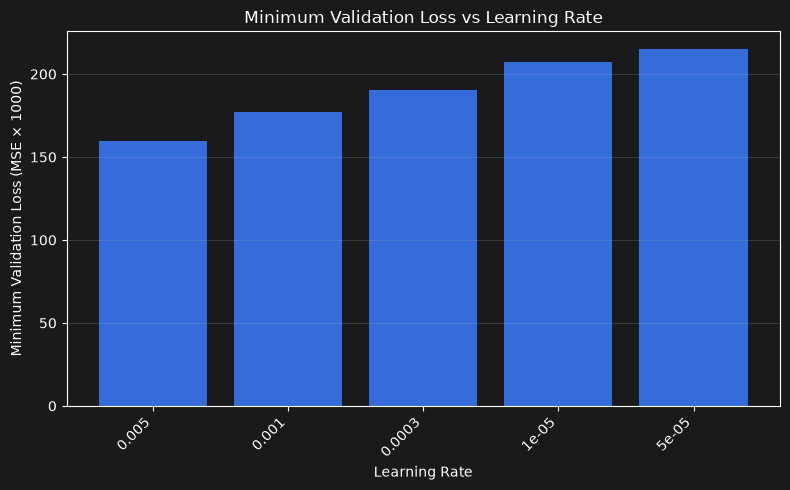

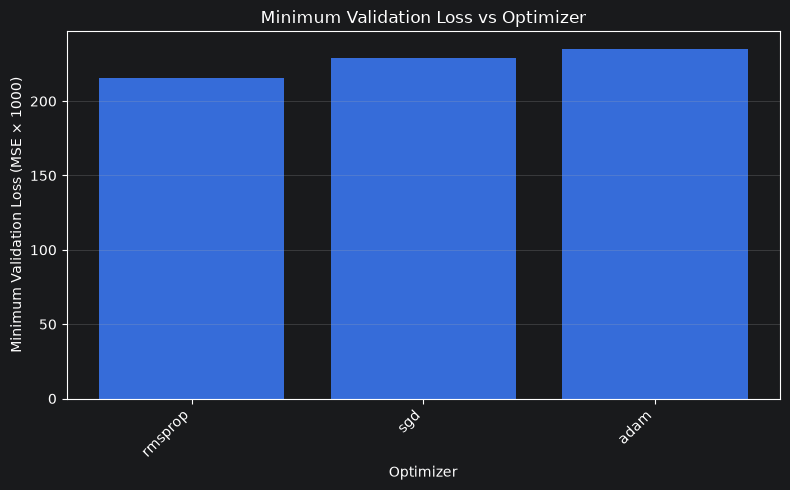

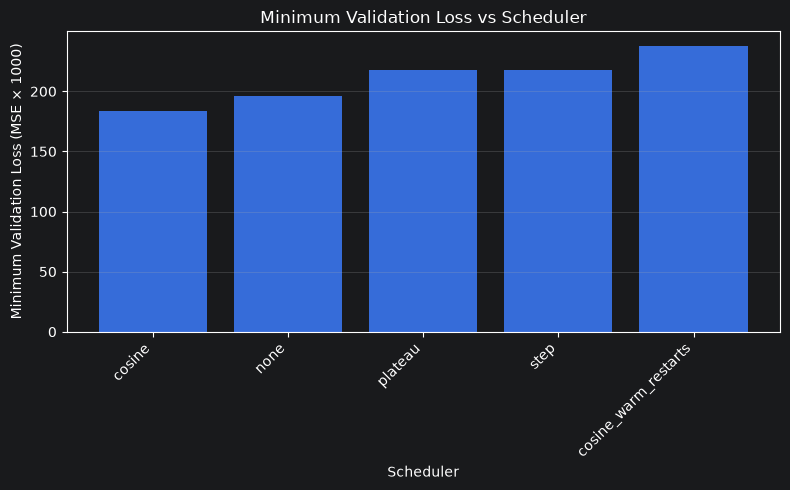

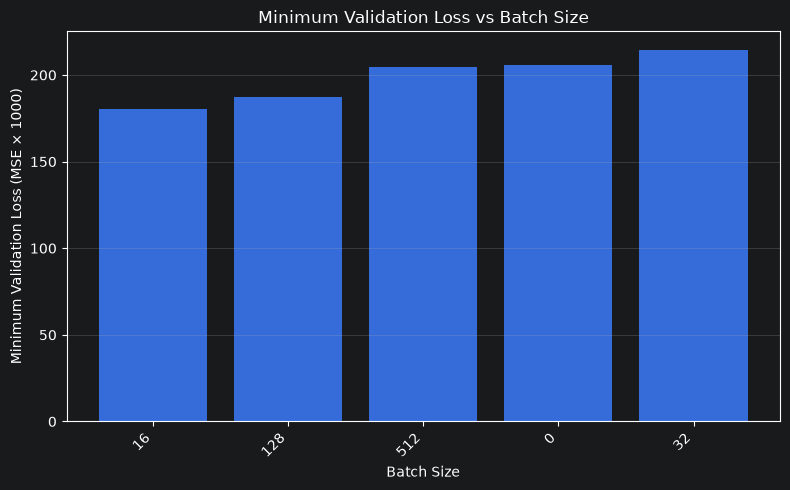

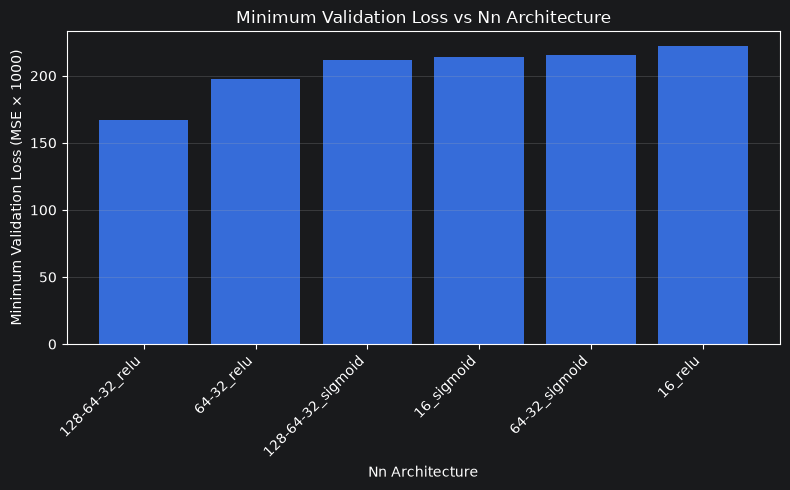

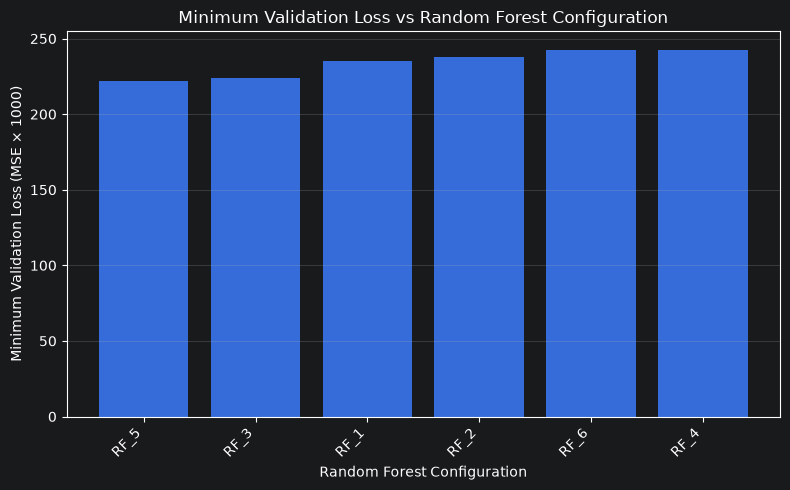

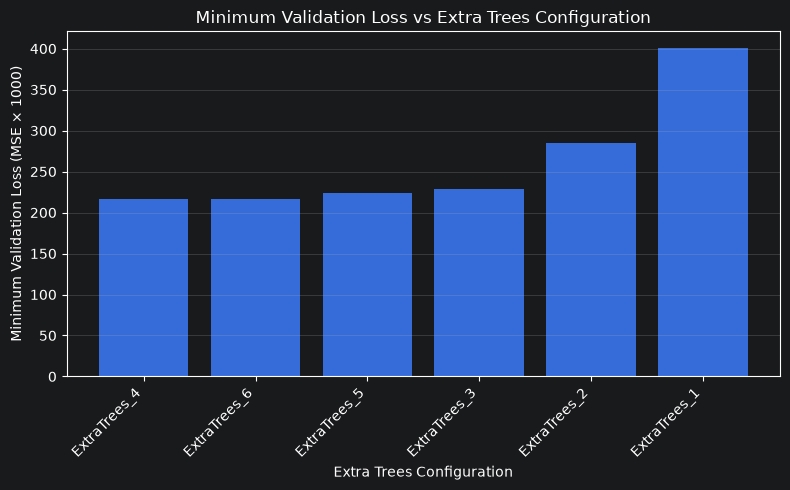

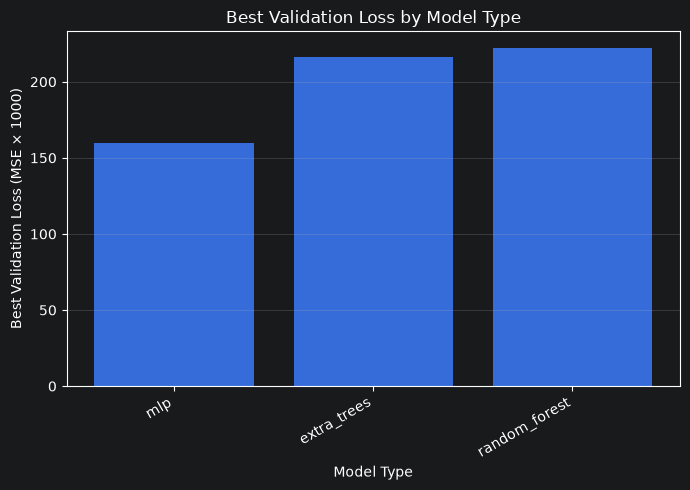

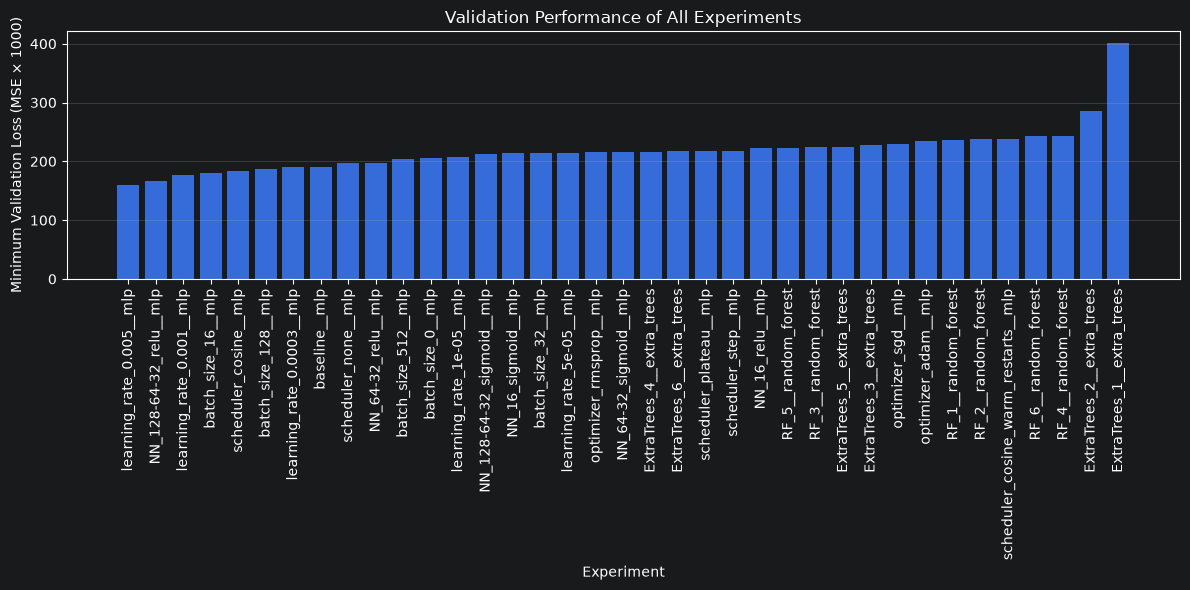

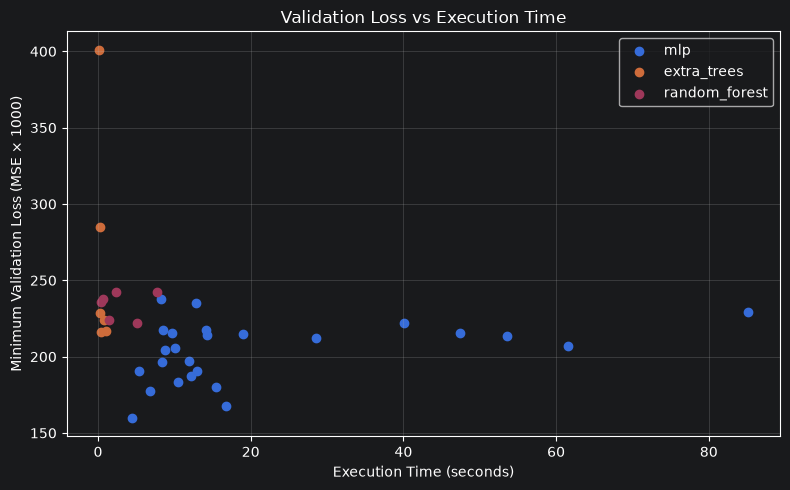

,run_name,model_type,best_train_loss,best_val_loss,val_mse,val_mae,val_r2,best_step,execution_time_sec
0,learning_rate_0.005__mlp,mlp,18.257914,159.751490,858.893188,19.431465,0.791472,331,4.417167
1,NN_128-64-32_relu__mlp,mlp,45.981415,167.343810,899.712708,19.029440,0.781562,1663,16.819593
2,learning_rate_0.001__mlp,mlp,41.927997,177.319139,953.344360,19.709002,0.768541,496,6.766022
3,batch_size_16__mlp,mlp,198.983938,180.125684,968.433777,20.856785,0.764877,154,15.478152
4,scheduler_cosine__mlp,mlp,141.634494,183.649257,987.378174,21.339222,0.760278,977,10.541458
5,batch_size_128__mlp,mlp,210.259050,187.433511,1007.723877,21.115013,0.755338,806,12.142100
6,learning_rate_0.0003__mlp,mlp,182.343408,190.376922,1023.548767,21.284592,0.751496,413,5.369144
7,baseline__mlp,mlp,230.120644,190.459102,1023.990784,21.905542,0.751388,946,12.944912
8,scheduler_none__mlp,mlp,179.526255,196.466088,1056.286865,21.314823,0.743547,888,8.442298
9,NN_64-32_relu__mlp,mlp,182.374448,197.468027,1061.673950,21.529800,0.742239,1248,11.914852



OVERALL CHAMPION
----------------
Run: learning_rate_0.005__mlp
Model type: mlp
Best validation loss: 159.75148975849152
Validation MSE: 858.8931884765625
Validation MAE: 19.43146514892578
Validation R²: 0.7914720177650452
Best training step: 331
Execution time: 4.4171666000038385 seconds


In [56]:
# ============================================================
# PERFORMANCE VISUALIZATION CELL
# ============================================================


# ============================================================
# 1. INDIVIDUAL TRAINING / VALIDATION LOSS CURVES
# ============================================================

def plot_loss_curve(history):

    plt.figure(figsize=(8, 5))

    plt.plot(
        history["x"],
        history["train_loss"],
        label="Training Loss"
    )

    plt.plot(
        history["x"],
        history["val_loss"],
        label="Validation Loss"
    )

    model_type = history["model_type"]

    # Appropriate x-axis depending on model type
    if model_type == "mlp":
        xlabel = "Epoch"

    elif model_type in [
        "random_forest",
        "extra_trees"
    ]:
        xlabel = "Number of Trees"

    else:
        xlabel = "Training Step"

    plt.xlabel(xlabel)
    plt.ylabel("MSE Loss × 1000")

    # Log scale makes large differences easier to see
    plt.yscale("log")

    plt.title(
        history["run_name"]
    )

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Plot first 10 experiments
#
# Change [:10] to [:] if you want EVERY loss curve.
# ------------------------------------------------------------

for run_name in list(histories.keys())[:10]:

    plot_loss_curve(
        histories[run_name]
    )


# ============================================================
# 2. GENERAL FACTOR COMPARISON FUNCTION
# ============================================================

def plot_factor(
    results_df,
    factor,
    metric="best_val_loss",
    log_x=False
):

    subset = results_df[
        results_df["factor"] == factor
    ].copy()

    if len(subset) == 0:

        print(
            f"No results found for factor: {factor}"
        )

        return

    plt.figure(figsize=(8, 5))

    x = subset["setting"]
    y = subset[metric]

    # --------------------------------------------------------
    # Numeric settings
    # Examples:
    # learning rate
    # batch size
    # --------------------------------------------------------

    if pd.api.types.is_numeric_dtype(x):

        subset = subset.sort_values(
            "setting"
        )

        x = subset["setting"]
        y = subset[metric]

        plt.plot(
            x,
            y,
            marker="o"
        )

        if log_x:
            plt.xscale("log")

    # --------------------------------------------------------
    # Categorical settings
    # Examples:
    # optimizer
    # scheduler
    # architecture
    # --------------------------------------------------------

    else:

        plt.bar(
            x.astype(str),
            y
        )

        plt.xticks(
            rotation=45,
            ha="right"
        )

    plt.xlabel(
        factor.replace("_", " ").title()
    )

    plt.ylabel(
        "Minimum Validation Loss (MSE × 1000)"
    )

    plt.title(
        f"Minimum Validation Loss vs "
        f"{factor.replace('_', ' ').title()}"
    )

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 3. LEARNING RATE
# ============================================================

plot_factor(
    results_df,
    factor="learning_rate",
    metric="best_val_loss",
    log_x=True
)


# ============================================================
# 4. OPTIMIZER
# ============================================================

plot_factor(
    results_df,
    factor="optimizer",
    metric="best_val_loss"
)


# ============================================================
# 5. SCHEDULER
# ============================================================

plot_factor(
    results_df,
    factor="scheduler",
    metric="best_val_loss"
)


# ============================================================
# 6. BATCH SIZE
# ============================================================

plot_factor(
    results_df,
    factor="batch_size",
    metric="best_val_loss"
)


# ============================================================
# 7. NEURAL NETWORK ARCHITECTURE / ACTIVATION
# ============================================================

plot_factor(
    results_df,
    factor="nn_architecture",
    metric="best_val_loss"
)


# ============================================================
# 8. RANDOM FOREST CONFIGURATION
# ============================================================

plot_factor(
    results_df,
    factor="random_forest_configuration",
    metric="best_val_loss"
)


# ============================================================
# 9. EXTRA TREES CONFIGURATION
# ============================================================

plot_factor(
    results_df,
    factor="extra_trees_configuration",
    metric="best_val_loss"
)


# ============================================================
# 10. MODEL TYPE COMPARISON
#
# Compare the best result achieved by each model family
# ============================================================

model_comparison = (
    results_df
    .groupby("model_type", as_index=False)
    ["best_val_loss"]
    .min()
    .sort_values("best_val_loss")
)

plt.figure(figsize=(7, 5))

plt.bar(
    model_comparison["model_type"],
    model_comparison["best_val_loss"]
)

plt.xlabel(
    "Model Type"
)

plt.ylabel(
    "Best Validation Loss (MSE × 1000)"
)

plt.title(
    "Best Validation Loss by Model Type"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 11. ALL EXPERIMENTS
#
# Useful for identifying the overall winner
# ============================================================

ordered_results = results_df.sort_values(
    "best_val_loss",
    ascending=True
)

plt.figure(figsize=(12, 6))

plt.bar(
    ordered_results["run_name"],
    ordered_results["best_val_loss"]
)

plt.xlabel(
    "Experiment"
)

plt.ylabel(
    "Minimum Validation Loss (MSE × 1000)"
)

plt.title(
    "Validation Performance of All Experiments"
)

plt.xticks(
    rotation=90
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 12. VALIDATION LOSS VS TRAINING TIME
#
# Helpful later for champion-model discussion
# ============================================================

plt.figure(figsize=(8, 5))

for model_type in results_df["model_type"].unique():

    subset = results_df[
        results_df["model_type"] == model_type
    ]

    plt.scatter(
        subset["execution_time_sec"],
        subset["best_val_loss"],
        label=model_type
    )

plt.xlabel(
    "Execution Time (seconds)"
)

plt.ylabel(
    "Minimum Validation Loss (MSE × 1000)"
)

plt.title(
    "Validation Loss vs Execution Time"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 13. BEST MODELS TABLE
# ============================================================

display_columns = [
    "run_name",
    "model_type",
    "best_train_loss",
    "best_val_loss",
    "val_mse",
    "val_mae",
    "val_r2",
    "best_step",
    "execution_time_sec"
]

top_models = (
    results_df
    .sort_values(
        "best_val_loss",
        ascending=True
    )
    [display_columns]
    .head(15)
)

display(
    top_models
)


# ============================================================
# 14. PRINT OVERALL CHAMPION
# ============================================================

champion = (
    results_df
    .sort_values(
        "best_val_loss",
        ascending=True
    )
    .iloc[0]
)

print("\nOVERALL CHAMPION")
print("----------------")

print(
    "Run:",
    champion["run_name"]
)

print(
    "Model type:",
    champion["model_type"]
)

print(
    "Best validation loss:",
    champion["best_val_loss"]
)

print(
    "Validation MSE:",
    champion["val_mse"]
)

print(
    "Validation MAE:",
    champion["val_mae"]
)

print(
    "Validation R²:",
    champion["val_r2"]
)

print(
    "Best training step:",
    champion["best_step"]
)

print(
    "Execution time:",
    champion["execution_time_sec"],
    "seconds"
)

In [57]:
# ============================================================
# SAVE ALL RESULTS AND FIGURES
# ============================================================

from pathlib import Path
import re
import json

# Main output directory
output_dir = Path("10_percent_run")

# Separate plots folder
plots_dir = output_dir / "plots"

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

plots_dir.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# HELPER: SAFE FILENAMES
# ============================================================

def safe_filename(name):

    return re.sub(
        r'[^A-Za-z0-9_.-]+',
        '_',
        str(name)
    )


# ============================================================
# 1. SAVE RESULTS DATAFRAMES
# ============================================================

results_df.to_csv(
    output_dir / "results_df.csv",
    index=False
)

top_models.to_csv(
    output_dir / "top_models.csv",
    index=False
)

model_comparison.to_csv(
    output_dir / "model_comparison.csv",
    index=False
)

ordered_results.to_csv(
    output_dir / "ordered_results.csv",
    index=False
)


# ============================================================
# 2. SAVE CHAMPION INFORMATION
# ============================================================

champion_df = pd.DataFrame(
    [champion]
)

champion_df.to_csv(
    output_dir / "champion.csv",
    index=False
)


# ============================================================
# 3. SAVE ALL LOSS HISTORIES AS ONE DATAFRAME
#
# This is useful because it preserves every train/validation
# loss point for every run.
# ============================================================

history_rows = []

for run_name, history in histories.items():

    for step, train_loss, val_loss in zip(
        history["x"],
        history["train_loss"],
        history["val_loss"]
    ):

        history_rows.append(
            {
                "run_name": run_name,
                "model_type": history["model_type"],
                "step": step,
                "train_loss": train_loss,
                "val_loss": val_loss
            }
        )

histories_df = pd.DataFrame(
    history_rows
)

histories_df.to_csv(
    output_dir / "all_loss_histories.csv",
    index=False
)


# ============================================================
# 4. SAVE SELECTED FEATURES
# ============================================================

with open(
    output_dir / "selected_features.txt",
    "w"
) as f:

    for feature in selected_features:

        f.write(
            f"{feature}\n"
        )


# ============================================================
# 5. SAVE INDIVIDUAL LOSS CURVES
#
# Save EVERY experiment, not just the first 10.
# ============================================================

for run_name, history in histories.items():

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        history["x"],
        history["train_loss"],
        label="Training Loss"
    )

    plt.plot(
        history["x"],
        history["val_loss"],
        label="Validation Loss"
    )

    if history["model_type"] == "mlp":

        xlabel = "Epoch"

    elif history["model_type"] in [
        "random_forest",
        "extra_trees"
    ]:

        xlabel = "Number of Trees"

    else:

        xlabel = "Training Step"

    plt.xlabel(
        xlabel
    )

    plt.ylabel(
        "MSE Loss × 1000"
    )

    plt.yscale(
        "log"
    )

    plt.title(
        run_name
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    filename = (
        safe_filename(run_name)
        + "_loss_curve.png"
    )

    plt.savefig(
        plots_dir / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


# ============================================================
# 6. SAVE FACTOR COMPARISON PLOTS
# ============================================================

factors_to_plot = [
    ("learning_rate", True),
    ("optimizer", False),
    ("scheduler", False),
    ("batch_size", False),
    ("nn_architecture", False),
    ("random_forest_configuration", False),
    ("extra_trees_configuration", False)
]


for factor, log_x in factors_to_plot:

    subset = results_df[
        results_df["factor"] == factor
    ].copy()

    if len(subset) == 0:

        continue

    plt.figure(
        figsize=(8, 5)
    )

    x = subset["setting"]
    y = subset["best_val_loss"]

    # Numeric setting
    if pd.api.types.is_numeric_dtype(x):

        subset = subset.sort_values(
            "setting"
        )

        x = subset["setting"]
        y = subset["best_val_loss"]

        plt.plot(
            x,
            y,
            marker="o"
        )

        if log_x:

            plt.xscale(
                "log"
            )

    # Categorical setting
    else:

        plt.bar(
            x.astype(str),
            y
        )

        plt.xticks(
            rotation=45,
            ha="right"
        )

    factor_title = (
        factor
        .replace("_", " ")
        .title()
    )

    plt.xlabel(
        factor_title
    )

    plt.ylabel(
        "Minimum Validation Loss (MSE × 1000)"
    )

    plt.title(
        f"Minimum Validation Loss vs {factor_title}"
    )

    plt.grid(
        axis="y",
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        plots_dir / f"{factor}_comparison.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


# ============================================================
# 7. SAVE MODEL TYPE COMPARISON
# ============================================================

plt.figure(
    figsize=(7, 5)
)

plt.bar(
    model_comparison["model_type"],
    model_comparison["best_val_loss"]
)

plt.xlabel(
    "Model Type"
)

plt.ylabel(
    "Best Validation Loss (MSE × 1000)"
)

plt.title(
    "Best Validation Loss by Model Type"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    plots_dir / "model_type_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# 8. SAVE ALL EXPERIMENTS COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 6)
)

plt.bar(
    ordered_results["run_name"],
    ordered_results["best_val_loss"]
)

plt.xlabel(
    "Experiment"
)

plt.ylabel(
    "Minimum Validation Loss (MSE × 1000)"
)

plt.title(
    "Validation Performance of All Experiments"
)

plt.xticks(
    rotation=90
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    plots_dir / "all_experiments_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# 9. SAVE VALIDATION LOSS VS EXECUTION TIME
# ============================================================

plt.figure(
    figsize=(8, 5)
)

for model_type in results_df[
    "model_type"
].unique():

    subset = results_df[
        results_df["model_type"] == model_type
    ]

    plt.scatter(
        subset["execution_time_sec"],
        subset["best_val_loss"],
        label=model_type
    )

plt.xlabel(
    "Execution Time (seconds)"
)

plt.ylabel(
    "Minimum Validation Loss (MSE × 1000)"
)

plt.title(
    "Validation Loss vs Execution Time"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    plots_dir / "validation_loss_vs_execution_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# FINISHED
# ============================================================

print(
    f"All results saved to: {output_dir.resolve()}"
)

print(
    f"Plots saved to: {plots_dir.resolve()}"
)

print(
    f"Total plots saved: "
    f"{len(list(plots_dir.glob('*.png')))}"
)

All results saved to: C:\Users\stlma\Documents\MIZZOU\github\mizzou_atomistic_materials_analytics_fs2026\01_Structure_to_Boiling_Point\10_percent_run
Plots saved to: C:\Users\stlma\Documents\MIZZOU\github\mizzou_atomistic_materials_analytics_fs2026\01_Structure_to_Boiling_Point\10_percent_run\plots
Total plots saved: 47


custom_adam_lr001_batch16__mlp | Epoch 100 | Train = 64.326 | Val = 209.583
custom_adam_lr001_batch16__mlp | Epoch 200 | Train = 55.328 | Val = 228.078
custom_adam_lr001_batch16__mlp | Epoch 300 | Train = 37.308 | Val = 220.035
Early stopping at epoch 350


,run_name,experiment,model_type,learning_rate,optimizer,scheduler,batch_size,model_params,best_step,best_train_loss,best_val_loss,final_val_loss,val_mse,val_mae,val_r2,execution_time_sec,n_train,n_validation,factor,setting
0,custom_adam_lr001_batch16__mlp,custom_adam_lr001_batch16,mlp,0.001,adam,none,16,"{""activation"": ""relu"", ""hidden_layers"": [64, 32]}",50,85.95033,198.069498,198.069528,977.010925,18.868052,0.821577,115.700144,2648,662,combined_settings,adam_lr001_batch16_no_scheduler


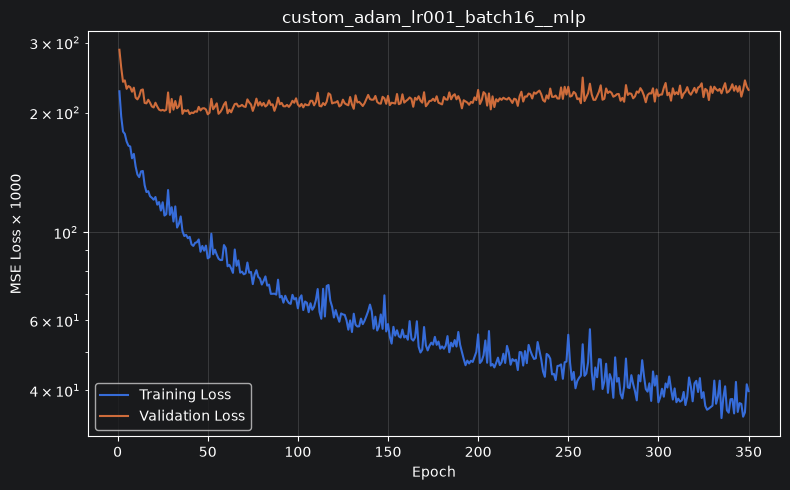

Best validation loss: 198.069
Best epoch: 50
Validation MAE: 18.868
Validation R²: 0.8216
Execution time: 115.70 seconds


In [8]:
# ============================================================
# CUSTOM MLP EXPERIMENT
# Batch size: 16
# Optimizer: Adam
# Learning rate: 0.001
# Scheduler: None
# Architecture: 64 → 32, ReLU (baseline)
# ============================================================

def plot_loss_curve(history):

    plt.figure(figsize=(8, 5))

    plt.plot(
        history["x"],
        history["train_loss"],
        label="Training Loss"
    )

    plt.plot(
        history["x"],
        history["val_loss"],
        label="Validation Loss"
    )

    model_type = history["model_type"]

    # Appropriate x-axis depending on model type
    if model_type == "mlp":
        xlabel = "Epoch"

    elif model_type in [
        "random_forest",
        "extra_trees"
    ]:
        xlabel = "Number of Trees"

    else:
        xlabel = "Training Step"

    plt.xlabel(xlabel)
    plt.ylabel("MSE Loss × 1000")

    # Log scale makes large differences easier to see
    plt.yscale("log")

    plt.title(
        history["run_name"]
    )

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

results_champ = []
histories_champ = {}

custom_params = {
    "hidden_layers": [64, 32],
    "activation": "relu"
}

row, history = train_model(
    X,
    y,

    model_type="mlp",
    model_params=custom_params,

    learning_rate=0.001,
    optimizer_name="adam",
    scheduler_name="none",
    batch_size=16,

    max_epochs=10000,
    patience=300,

    experiment_name="custom_adam_lr001_batch16",
    verbose=True
)

# Store results alongside previous experiments
row["factor"] = "combined_settings"
row["setting"] = "adam_lr001_batch16_no_scheduler"

results_champ.append(row)
histories_champ[row["run_name"]] = history

# Update results dataframe
results_df = pd.DataFrame(results_champ).sort_values(
    "best_val_loss"
).reset_index(drop=True)

# Display results
display(pd.DataFrame([row]))

# Plot training and validation loss
plot_loss_curve(history)

print(f"Best validation loss: {row['best_val_loss']:.3f}")
print(f"Best epoch: {row['best_step']}")
print(f"Validation MAE: {row['val_mae']:.3f}")
print(f"Validation R²: {row['val_r2']:.4f}")
print(f"Execution time: {row['execution_time_sec']:.2f} seconds")